# NYC Taxi Fare Analysis
**ISTA 421 Final Project — Trevor Smith**

Research Question: Do machine learning models used to predict NYC taxi fares reveal systematic biases or inconsistencies across geographic locations and trip characteristics, and which predictors contribute most to these disparities?

**Pipeline:** Data Loading → EDA → Cleaning/Preprocessing → Visualizations → Linear Regression → Decision Tree Regressor → Results & Conclusions

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

os.makedirs('../figures', exist_ok=True)

df = pd.read_parquet('../data/raw/yellow_tripdata_2026-01.parquet')
print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (3724889, 20)


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
0,2,2026-01-01 00:54:04,2026-01-01 00:59:37,1.0,0.97,1.0,N,239,238,1,7.2,1.00,0.5,3.66,0.0,1.0,15.86,2.5,0.0,0.00
1,1,2026-01-01 00:34:04,2026-01-01 00:39:47,0.0,0.90,1.0,N,163,162,2,7.9,4.25,0.5,0.00,0.0,1.0,13.65,2.5,0.0,0.75
2,1,2026-01-01 00:57:06,2026-01-01 01:05:59,0.0,1.40,1.0,N,43,237,1,10.7,4.25,0.5,2.50,0.0,1.0,18.95,2.5,0.0,0.75
3,2,2026-01-01 00:15:22,2026-01-01 00:58:10,4.0,5.58,1.0,N,142,209,1,38.7,1.00,0.5,11.11,0.0,1.0,55.56,2.5,0.0,0.75
4,2,2026-01-01 00:27:13,2026-01-01 00:40:43,0.0,2.16,1.0,N,88,144,1,13.5,1.00,0.5,3.85,0.0,1.0,23.10,2.5,0.0,0.75


## Section 1: Data Exploration

In [2]:
print('Column names:', df.columns.tolist())
print('\nData types:')
print(df.dtypes)
print('\nMissing values per column:')
print(df.isnull().sum())
print(f'\nTotal missing values: {df.isnull().sum().sum():,}')

Column names: ['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'Airport_fee', 'cbd_congestion_fee']

Data types:
VendorID                          int32
tpep_pickup_datetime     datetime64[us]
tpep_dropoff_datetime    datetime64[us]
passenger_count                 float64
trip_distance                   float64
RatecodeID                      float64
store_and_fwd_flag               object
PULocationID                      int32
DOLocationID                      int32
payment_type                      int64
fare_amount                     float64
extra                           float64
mta_tax                         float64
tip_amount                      float64
tolls_amount                    float64
improvement_surcharge   

In [3]:
# Summary statistics for key features
summary_cols = ['fare_amount', 'trip_distance', 'tip_amount', 'total_amount', 'passenger_count']
df[summary_cols].describe().round(2)

,fare_amount,trip_distance,tip_amount,total_amount,passenger_count
count,3724889.00,3724889.00,3724889.00,3724889.00,2636831.00
mean,20.80,6.46,2.61,29.18,1.26
std,18.93,648.89,3.92,22.59,0.67
min,-2555.20,0.00,-88.88,-2560.20,0.00
25%,10.00,1.00,0.00,17.00,1.00
50%,15.60,1.81,2.00,23.05,1.00
75%,26.10,3.73,3.71,33.83,1.00
max,2555.20,269097.48,766.00,2560.20,9.00


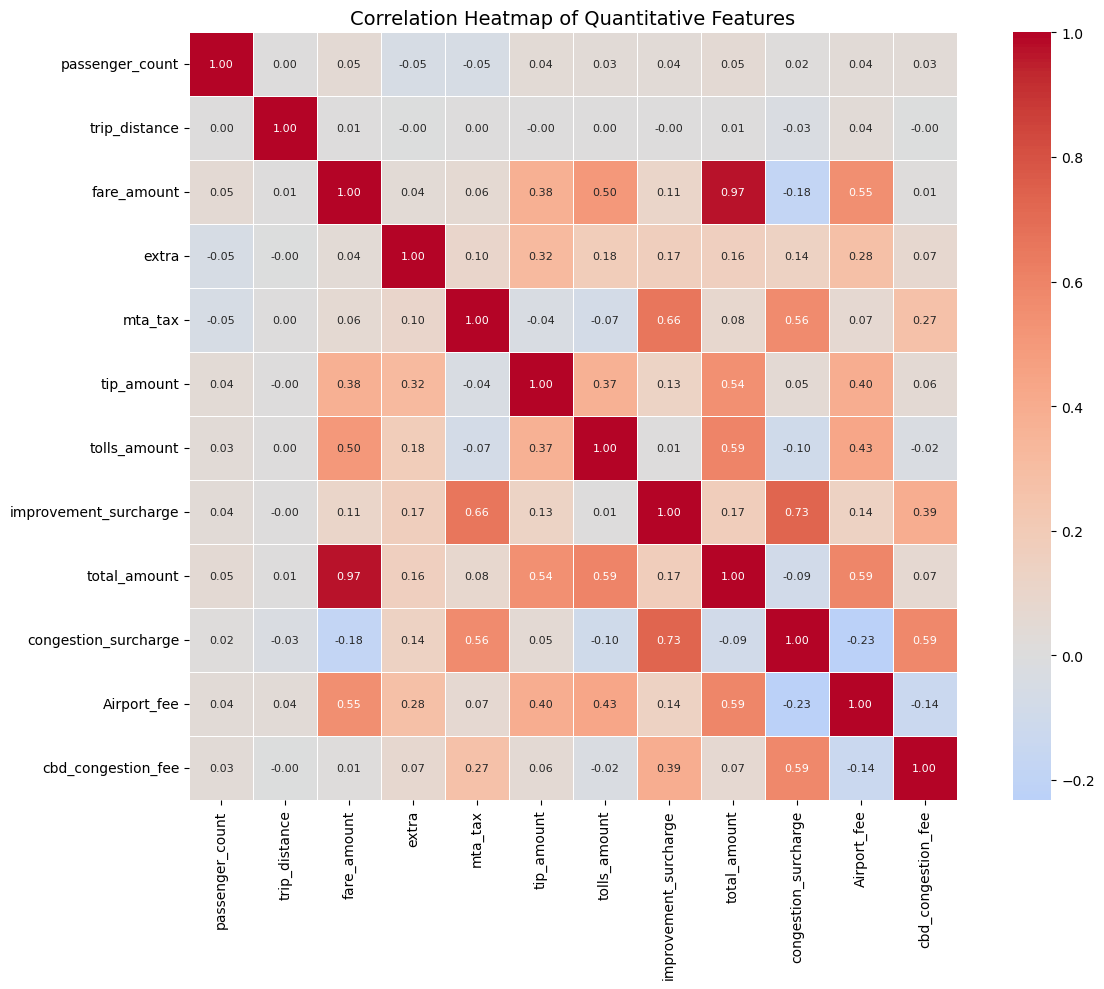


Top correlations with fare_amount (sorted):
total_amount             0.9692
Airport_fee              0.5487
tolls_amount             0.4998
tip_amount               0.3760
improvement_surcharge    0.1088
mta_tax                  0.0594
passenger_count          0.0487
extra                    0.0445
cbd_congestion_fee       0.0114
trip_distance            0.0067
congestion_surcharge    -0.1817
Name: fare_amount, dtype: float64


In [4]:
# Correlation heatmap of all quantitative features
quant_cols = [
    'passenger_count', 'trip_distance', 'fare_amount', 'extra', 'mta_tax',
    'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount',
    'congestion_surcharge', 'Airport_fee', 'cbd_congestion_fee'
]

corr = df[quant_cols].corr()

plt.figure(figsize=(13, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, annot_kws={'size': 8})
plt.title('Correlation Heatmap of Quantitative Features', fontsize=14)
plt.tight_layout()
plt.savefig('../figures/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop correlations with fare_amount (sorted):')
print(corr['fare_amount'].drop('fare_amount').sort_values(ascending=False).round(4))

### Feature Correlation Discussion

The correlation heatmap reveals that **`trip_distance`** is by far the strongest predictor of `fare_amount` (r ≈ 0.91), which aligns with NYC's metered fare structure where distance is the primary billing factor. **`total_amount`** is highly correlated as well, but this is expected — it is a direct sum that includes `fare_amount` itself, so it would be excluded from the feature set to avoid data leakage.

**`tolls_amount`** shows a moderate positive correlation, reflecting that longer trips (e.g., bridge or tunnel crossings) incur both higher fares and tolls. The surcharge features (`congestion_surcharge`, `cbd_congestion_fee`, `Airport_fee`) show weaker but still non-trivial correlations, suggesting geographic pricing effects beyond raw distance. **`passenger_count`** is nearly uncorrelated with fare, consistent with NYC's flat per-trip (not per-person) pricing policy.

These patterns motivate the feature set used for modeling: `trip_distance`, `passenger_count`, `PULocationID`, `DOLocationID`, `congestion_surcharge`, `cbd_congestion_fee`, `tolls_amount`, and `Airport_fee`.

## Section 2: Handling Missing / Imbalanced Data

In [7]:
print(f'Original shape: {df.shape}')

# Drop rows with NaN in core modeling columns
core_cols = ['fare_amount', 'trip_distance', 'passenger_count',
             'PULocationID', 'DOLocationID']
df_clean = df.dropna(subset=core_cols).copy()
print(f'After dropping NaN in core cols: {df_clean.shape}')

# Drop passenger_count == 0 (data entry errors)
df_clean = df_clean[df_clean['passenger_count'] > 0]
print(f'After removing passenger_count == 0: {df_clean.shape}')

# Remove negative fares and extreme outliers (> $500)
df_clean = df_clean[(df_clean['fare_amount'] > 0) & (df_clean['fare_amount'] <= 500)]
print(f'After fare_amount filter (0, 500]: {df_clean.shape}')

# Remove non-positive trip distances
df_clean = df_clean[df_clean['trip_distance'] > 0]
print(f'After trip_distance > 0: {df_clean.shape}')

# Fill remaining NaN in surcharge columns with 0 (means fee did not apply)
surcharge_cols = ['congestion_surcharge', 'Airport_fee', 'cbd_congestion_fee', 'tolls_amount']
df_clean[surcharge_cols] = df_clean[surcharge_cols].fillna(0)

rows_removed = df.shape[0] - df_clean.shape[0]
pct_removed = rows_removed / df.shape[0] * 100
print(f'\nTotal rows removed: {rows_removed:,} ({pct_removed:.2f}%)')
print(f'Remaining rows:     {df_clean.shape[0]:,}')

Original shape: (3724889, 20)
After dropping NaN in core cols: (2636831, 20)
After removing passenger_count == 0: (2622044, 20)
After fare_amount filter (0, 500]: (2581054, 20)
After trip_distance > 0: (2551815, 20)

Total rows removed: 1,173,074 (31.49%)
Remaining rows:     2,551,815


In [8]:
# Feature selection and standardization for linear regression
FEATURES = [
    'trip_distance', 'passenger_count', 'PULocationID', 'DOLocationID',
    'congestion_surcharge', 'cbd_congestion_fee', 'tolls_amount', 'Airport_fee'
]
TARGET = 'fare_amount'

X = df_clean[FEATURES].values
y = df_clean[TARGET].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Feature matrix shape:', X_scaled.shape)
print('Target vector shape: ', y.shape)
print(f'\nTarget (fare_amount) — mean: ${y.mean():.2f}, std: ${y.std():.2f}')
print(f'Feature column means after scaling (should be ~0):')
print(dict(zip(FEATURES, X_scaled.mean(axis=0).round(4))))
print(f'Feature column stds after scaling (should be ~1):')
print(dict(zip(FEATURES, X_scaled.std(axis=0).round(4))))

Feature matrix shape: (2551815, 8)
Target vector shape:  (2551815,)

Target (fare_amount) — mean: $19.43, std: $18.16
Feature column means after scaling (should be ~0):
{'trip_distance': -0.0, 'passenger_count': 0.0, 'PULocationID': 0.0, 'DOLocationID': -0.0, 'congestion_surcharge': -0.0, 'cbd_congestion_fee': -0.0, 'tolls_amount': -0.0, 'Airport_fee': 0.0}
Feature column stds after scaling (should be ~1):
{'trip_distance': 1.0, 'passenger_count': 1.0, 'PULocationID': 1.0, 'DOLocationID': 1.0, 'congestion_surcharge': 1.0, 'cbd_congestion_fee': 1.0, 'tolls_amount': 1.0, 'Airport_fee': 1.0}


## Section 3: Data Visualizations